# Assignment 2, Part 2: Pedestrians on Eindhoven Centraal

In this notebook you model the future motion of pedestrians on platforms 3 and 4 of Eindhoven Centraal. Given the first 10 observed frames of a scene, you generate the remaining 20 frames for all pedestrians using conditional flow matching with time bundling.

You implement and compare two models:
1. a model with an uninformed Gaussian prior on the future velocities;
2. a model with an informed, data dependent prior.

The focus is not on model performance, but on an architecture that fits the problem formulation and on the comparison between the two priors. Every group member must be able to explain the model design and interpret the results. The full task description is in Section 2 of the assignment PDF.

In [ ]:
import gdown
from pathlib import Path
import pickle
import torch
from torch.utils.data import Dataset
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from lightning import LightningDataModule, LightningModule, Trainer
import math
import warnings
import matplotlib.pyplot as plt
import numpy as np

## Dataset

The dataset contains 100,000 samples. Each sample is a scene with 5 to 100 pedestrians, stored as an array of shape `(N, 30, 2)`: the 2D positions in metres of `N` pedestrians over 30 frames, spaced $\Delta t = 0.5$ s apart (15 s in total). Every pedestrian is present in all 30 frames.

The cell below downloads the data (about 290 MB).

In [ ]:
drive_link = "https://drive.google.com/file/d/1sU_gti1xg2AB_SQINy_cZZm4jxE9lbIm/view?usp=drive_link"

DATA_PATH = Path("eindhoven_centraal.pkl")

if not DATA_PATH.exists():

    print("Downloading dataset...")

    gdown.download(
        url=drive_link,
        output=str(DATA_PATH),
        quiet=False,
    )

    print(
        "Download complete:",
        DATA_PATH,
    )

else:
    print(
        "Dataset already available:",
        DATA_PATH,
    )

Dataset already available: eindhoven_centraal.pkl


## Data loading and graph construction

`PedestriansDataset` loads the samples and turns each one into a graph:

* **Nodes** are pedestrians. The node features `x` are the full trajectories, with shape `(N, 30, 2)`.
* **Edges** are fixed over time: the same `edge_index` of shape `(2, E)` is used for every frame. The example graph is fully connected without self loops, so $E = N(N-1)$.

After batching with the PyG `DataLoader`, `x` has shape `(sum N, 30, 2)`, the edges of each scene are offset so they never connect different scenes, and `batch` gives the scene index of every pedestrian.

A fully connected graph grows with $N^2$ and connects pedestrians that are far apart and do not interact. You can and should implement a less connected graph in `make_edge_index`, for example a radius or k nearest neighbour graph. Such a graph may only be built from the observed frames 0 to 9, since the target frames are not available at inference.

`GraphDataModule` splits the samples randomly at sample level with a fixed seed, so no scene appears in more than one split. The test set must contain at least 1,000 samples; a larger test set is preferred. Normalization statistics must be computed on the training split only.

In [ ]:
class PedestriansDataset(Dataset):
    """Pedestrian scenes as graphs with an edge connectivity that is fixed over time.

    Every sample is one scene with N pedestrians over F = 30 frames. Nodes are pedestrians
    and the node features are their full trajectories:
        x:          (N, F, 2)   positions in metres
        edge_index: (2, E)      edges between pedestrians, shared by all frames

    After batching with the PyG DataLoader:
        x:          (sum N, F, 2)
        edge_index: (2, sum E)  offset per scene, so edges never cross scenes
        batch:      (sum N,)    scene index of every pedestrian
    """

    def __init__(self, path, n_samples=None, T_cond=10):
        self.T_cond = T_cond
        self.raw_data = self._load_data(path)
        if n_samples is not None:
            self.raw_data = self.raw_data[:n_samples]
        print(f"Using {len(self.raw_data)} samples.")

    def _load_data(self, path):
        with open(path, "rb") as f:
            data = pickle.load(f)
        data = [torch.tensor(sample, dtype=torch.float32) for sample in data]
        print(
            f"\nLoaded {len(data)} samples from {path}, containing in total "
            f"{sum(x.shape[0] for x in data)} trajectories of {data[0].shape[1]} frames.\n"
        )
        return data

    def make_edge_index(self, sample):
        """Fully connected graph between N pedestrians, without self loops. Shape: (2, N * (N - 1))."""
        # NOTE: A fully connected graph grows with N^2 and also connects pedestrians that are far
        # apart and do not interact. A less connected graph can and should be implemented here,
        # for example a radius graph or a k nearest neighbour graph. To avoid leaking information
        # about the future, such a graph may only be built from the observed frames 0 to T_cond - 1.
        N = sample.shape[0]
        not_self = ~torch.eye(N, dtype=torch.bool)  # True everywhere except the diagonal
        return not_self.nonzero().T.contiguous()

    def __len__(self):
        return len(self.raw_data)

    def __getitem__(self, idx):
        sample = self.raw_data[idx]  # (N, F, 2)
        N = sample.shape[0]
        return Data(x=sample, edge_index=self.make_edge_index(sample), num_nodes=N)


class GraphDataModule(LightningDataModule):
    """Random split at sample level, so no scene appears in more than one split."""

    def __init__(self, dataset, train_split, val_split, test_split, batch_size=8, seed=42, min_test_size=1000):
        super().__init__()
        if not math.isclose(train_split + val_split + test_split, 1.0):
            raise ValueError("train_split, val_split and test_split must sum to 1.")
        self.batch_size = batch_size
        self.seed = seed
        self.train_data, self.val_data, self.test_data = self.split_data(dataset, train_split, val_split)

        print(
            f"Split with seed {seed}: {len(self.train_data)} train, "
            f"{len(self.val_data)} validation, {len(self.test_data)} test samples."
        )
        if len(self.test_data) < min_test_size:
            warnings.warn(
                f"The test set contains {len(self.test_data)} samples, "
                f"but the assignment requires at least {min_test_size}."
            )

    def split_data(self, dataset, train_split, val_split):
        total_size = len(dataset)
        train_size = int(total_size * train_split)
        val_size = int(total_size * val_split)
        test_size = total_size - train_size - val_size

        return torch.utils.data.random_split(
            dataset,
            [train_size, val_size, test_size],
            generator=torch.Generator().manual_seed(self.seed),
        )

    def train_dataloader(self):
        return DataLoader(self.train_data, batch_size=self.batch_size, shuffle=True)  # type: ignore

    def val_dataloader(self):
        return DataLoader(self.val_data, batch_size=self.batch_size)  # type: ignore

    def test_dataloader(self):
        return DataLoader(self.test_data, batch_size=self.batch_size)  # type: ignore

    def predict_dataloader(self):
        return DataLoader(self.test_data, batch_size=self.batch_size)  # type: ignore

## Configuration

`n_samples` limits the number of samples for faster development. Make sure the final test set contains at least 1,000 samples, and report the seed and the size of each split.

In [ ]:
T_cond = 10

n_samples = 10000  # Limit to a number of samples for faster training during development

dataset = PedestriansDataset(
    DATA_PATH, n_samples=n_samples, T_cond=T_cond
) 

data_module = GraphDataModule(
    dataset, train_split=0.7, val_split=0.1, test_split=0.2, batch_size=16
)


Loaded 100000 samples from eindhoven_centraal.pkl, containing in total 2358008 trajectories of 30 frames.

Using 10000 samples.
Split with seed 42: 7000 train, 1000 validation, 2000 test samples.


## Visualization
This method can be used to visualize the pedestrian trajectories. Use it to double check if your generated samples are realistic.

Make sure you download the background image: https://github.com/vlamen/ml4sci-2026/blob/main/assignments/Eindhoven_centraal_platform_3_4.png

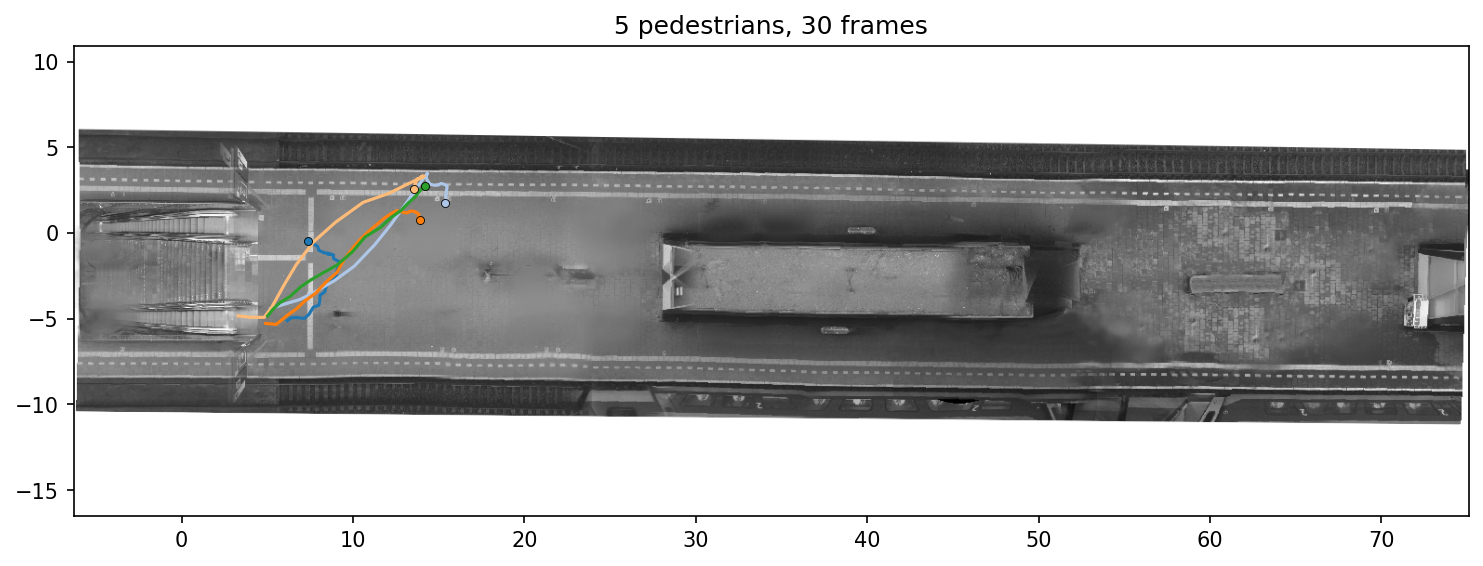

In [ ]:
EXTENT = (-6.309, 75.091, -16.539, 10.909)  # (left, right, bottom, top) of the background image in metres


def plot_sample(sample, background_path="Eindhoven_centraal_platform_3_4.png", ax=None,
                cmap_name="tab20", figsize=(12, 4.5), dpi=150):
    """Plot all trajectories of one data sample on the station background.

    sample: (N, F, 2) positions of N pedestrians over F frames, as a numpy array or torch tensor.
    The x and y axes of the data are swapped to match the background image.
    Each pedestrian gets its own color; the dot marks the final position.
    """
    if isinstance(sample, torch.Tensor):
        sample = sample.detach().cpu().numpy()
    traj = np.asarray(sample)[..., [1, 0]]  # Swap x and y

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
    else:
        fig = ax.figure

    ax.imshow(plt.imread(background_path), extent=EXTENT, origin="upper", zorder=0)
    ax.set_xlim(EXTENT[0], EXTENT[1])
    ax.set_ylim(EXTENT[2], EXTENT[3])

    cmap = plt.get_cmap(cmap_name)
    for i, t in enumerate(traj):
        color = cmap(i % cmap.N)
        ax.plot(t[:, 0], t[:, 1], color=color, lw=1.5, zorder=1)
        ax.scatter(t[-1, 0], t[-1, 1], color=color, s=15, edgecolors="black", linewidths=0.4, zorder=2)

    ax.set_title(f"{traj.shape[0]} pedestrians, {traj.shape[1]} frames")
    return fig, ax

plot_sample(dataset[0].x)
plt.show()

## Model architecture

Your model must capture patterns over **space**, the interactions between pedestrians, and over **time**, how the motion of each pedestrian evolves over the frames. As discussed in Practical 4, message passing handles space but not time, and flattening all frames into an MLP ignores temporal order and locality. Design an architecture that handles both axes, for example message passing over pedestrians combined with convolutions or attention over time.

Use the same architecture, training budget and sampler for both models, so that the prior is the only difference between them.

In [ ]:
import csv
import hashlib
import json
import random
import time
from torch import nn

# 1. Configuration and observed-only data
DT, H, K = 0.5, 10, 20
CFG = dict(seed=42, radius=3.0, max_neighbors=12, hidden_dim=64,
           num_blocks=3, sigma=1.0, recent_velocities=3, epochs=20,
           lr=1e-3, weight_decay=1e-4, ode_steps=30, num_futures=20,
           batch_size=data_module.batch_size, draw_chunk_size=4, allow_small_test=False,
           output_root="part2_continued")
# Optional overrides can be defined in a separate cell for a development run.
CFG.update(globals().get("PART2_CONFIG", {}))
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def seed_everything_part2(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True


class LocalPedestriansDataset(PedestriansDataset):
    """Randomly select scenes from the full file; build observed-only edges."""
    def __init__(self, path, n_samples=None, T_cond=10, radius=3.0,
                 max_neighbors=12, seed=42):
        if radius <= 0 or max_neighbors < 1 or T_cond != H:
            raise ValueError("Use a positive radius/cap and 10 observed frames.")
        self.radius, self.max_neighbors, self.selection_seed = radius, max_neighbors, seed
        self.selection_count = n_samples
        self.graph_cache = {}
        super().__init__(path, n_samples=n_samples, T_cond=T_cond)

    def _load_data(self, path):
        with open(path, "rb") as handle:
            raw = pickle.load(handle)
        # Select BEFORE truncation in the inherited constructor. This makes the
        # held-out scenes a random subset of the full 100,000-scene dataset.
        order = torch.randperm(
            len(raw), generator=torch.Generator().manual_seed(self.selection_seed))
        self.original_ids = order[:self.selection_count].tolist()
        return [torch.as_tensor(raw[i], dtype=torch.float32) for i in self.original_ids]

    def make_edge_index(self, sample):
        n = sample.shape[0]
        if n < 2:
            return torch.empty((2, 0), dtype=torch.long)
        distance = torch.cdist(sample[:, H - 1], sample[:, H - 1])
        distance.fill_diagonal_(float("inf"))
        # Each row is a receiver. Bound its incoming degree, using its nearest
        # neighbour only when there is no pedestrian inside the radius.
        near_distance, near_index = distance.topk(
            min(self.max_neighbors, n - 1), dim=1, largest=False)
        keep = near_distance < self.radius
        keep[~keep.any(dim=1), 0] = True
        receiver = torch.arange(n)[:, None].expand_as(near_index)
        return torch.stack((near_index[keep], receiver[keep]))

    def __getitem__(self, idx):
        sample = self.raw_data[idx]
        if idx not in self.graph_cache:
            edges = self.make_edge_index(sample)
            source, target = edges
            relative = sample[source, H - 1] - sample[target, H - 1]
            last_velocity = (sample[:, H - 1] - sample[:, H - 2]) / DT
            attributes = torch.cat((relative, relative.norm(dim=-1, keepdim=True),
                                    last_velocity[source] - last_velocity[target]), dim=-1)
            self.graph_cache[idx] = (edges, attributes)
        edges, attributes = self.graph_cache[idx]
        return Data(x=sample, edge_index=edges, edge_attr=attributes,
                    num_nodes=len(sample), scene_id=self.original_ids[idx])


# Preserve the supplied configuration cell while extending its dataset class.
dataset = LocalPedestriansDataset(DATA_PATH, n_samples=n_samples, T_cond=T_cond,
                                 radius=CFG["radius"], max_neighbors=CFG["max_neighbors"],
                                 seed=CFG["seed"])
data_module = GraphDataModule(dataset, train_split=0.7, val_split=0.1, test_split=0.2,
                             batch_size=CFG["batch_size"], seed=CFG["seed"])
if len(data_module.test_data) < 1000 and not CFG["allow_small_test"]:
    raise ValueError("Final evaluation requires at least 1000 held-out scenes.")


# 2. Training-only normalization and experiment identity
def training_statistics(subset):
    """Streaming moments and velocity persistence, using training scenes only."""
    moments = {key: [torch.zeros(2, dtype=torch.float64),
                     torch.zeros(2, dtype=torch.float64), 0]
               for key in ("position", "relative", "velocity")}
    gamma_num = gamma_den = 0.0
    for index in subset.indices:
        p = subset.dataset.raw_data[index].double()
        velocities = torch.diff(p, dim=1) / DT
        values = dict(position=p[:, :H], relative=p[:, :H] - p[:, H-1:H],
                      velocity=velocities)
        for key, value in values.items():
            value = value.reshape(-1, 2)
            moments[key][0] += value.sum(0)
            moments[key][1] += value.square().sum(0)
            moments[key][2] += len(value)
        gamma_num += (velocities[:, 1:] * velocities[:, :-1]).sum().item()
        gamma_den += velocities[:, :-1].square().sum().item()
    stats = {}
    for key, (total, squares, count) in moments.items():
        mean = total / count
        scale = (squares / count - mean.square()).clamp_min(1e-6).sqrt()
        if key == "relative":
            scale = (squares / count).clamp_min(1e-6).sqrt()
        stats[key + "_mean"] = mean.float()
        stats[key + "_std"] = scale.float()
    return stats, float(np.clip(gamma_num / max(gamma_den, 1e-12), 0, 1))


STATS, GAMMA = training_statistics(data_module.train_data)
MANIFEST = dict(selection_seed=CFG["seed"], split_seed=CFG["seed"],
                selected_scene_ids=dataset.original_ids,
                splits={name: [dataset.original_ids[i] for i in subset.indices]
                        for name, subset in (("train", data_module.train_data),
                                             ("validation", data_module.val_data),
                                             ("test", data_module.test_data))})
RUN_SPEC = dict(implementation="temporal_graph_v1", config=CFG, gamma=GAMMA,
                statistics={key: value.tolist() for key, value in STATS.items()},
                manifest=MANIFEST)
RUN_ID = hashlib.sha256(json.dumps(RUN_SPEC, sort_keys=True).encode()).hexdigest()[:12]
OUTPUT_DIR = Path(CFG["output_root"]) / RUN_ID
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
(OUTPUT_DIR / "run_spec.json").write_text(json.dumps(RUN_SPEC, indent=2), encoding="utf-8")
print(f"Device: {DEVICE}; persistence gamma: {GAMMA:.4f}; outputs: {OUTPUT_DIR}")


# 3. Shared temporal and graph vector-field network
class TemporalBlock(nn.Module):
    def __init__(self, width, dilation=1):
        super().__init__()
        self.convolutions = nn.Sequential(
            nn.Conv1d(width, width, 3, padding=dilation, dilation=dilation), nn.SiLU(),
            nn.Conv1d(width, width, 3, padding=dilation, dilation=dilation))
        self.norm = nn.LayerNorm(width)

    def forward(self, h):
        return self.norm(h + self.convolutions(h.transpose(1, 2)).transpose(1, 2))


class SpatialBlock(nn.Module):
    def __init__(self, width):
        super().__init__()
        self.message = nn.Sequential(nn.Linear(2 * width + 5, width), nn.SiLU(),
                                     nn.Linear(width, width))
        self.update = nn.Sequential(nn.Linear(2 * width, width), nn.SiLU(),
                                    nn.Linear(width, width))
        self.norm = nn.LayerNorm(width)

    def forward(self, h, edge_index, edge_attr):
        source, target = edge_index
        aggregate = torch.zeros_like(h)
        if source.numel():
            edge = edge_attr[:, None].expand(-1, h.shape[1], -1)
            messages = self.message(torch.cat((h[target], h[source], edge), dim=-1))
            aggregate.index_add_(0, target, messages)
            degree = torch.bincount(target, minlength=len(h)).clamp_min(1)
            aggregate = aggregate / degree[:, None, None]
        return self.norm(h + self.update(torch.cat((h, aggregate), dim=-1)))


class PedestrianVectorField(nn.Module):
    """[P,20,2] flow state -> [P,20,2] field; no physical autoregression."""
    def __init__(self, stats, width=64, num_blocks=3):
        super().__init__()
        for name, tensor in stats.items():
            self.register_buffer(name, tensor.clone())
        self.observed_input = nn.Linear(6, width)
        self.observed_temporal = nn.Sequential(TemporalBlock(width), TemporalBlock(width, 2))
        self.future_input = nn.Linear(2, width)
        self.frame_embedding = nn.Parameter(torch.randn(K, width) * 0.02)
        self.time_embedding = nn.Sequential(nn.Linear(16, width), nn.SiLU(),
                                            nn.Linear(width, width))
        self.register_buffer("time_frequencies", 2 ** torch.arange(8, dtype=torch.float32) * math.pi)
        self.temporal_blocks = nn.ModuleList([TemporalBlock(width, 2 ** (i % 3))
                                             for i in range(num_blocks)])
        self.spatial_blocks = nn.ModuleList([SpatialBlock(width) for _ in range(num_blocks)])
        self.head = nn.Sequential(nn.Linear(width, width), nn.SiLU(), nn.Linear(width, 2))

    def normalize_velocity(self, v):
        return (v - self.velocity_mean) / self.velocity_std

    def denormalize_velocity(self, v):
        return v * self.velocity_std + self.velocity_mean

    def encode_condition(self, batch):
        # Slice immediately: subsequent conditioning never sees target frames.
        obs = batch.x[:, :H]
        v = torch.diff(obs, dim=1) / DT
        v_aligned = torch.cat((v[:, :1], v), dim=1)
        relative = (obs - obs[:, -1:]) / self.relative_std
        absolute = ((obs[:, -1:] - self.position_mean) / self.position_std).expand(-1, H, -1)
        features = torch.cat((relative, absolute, self.normalize_velocity(v_aligned)), dim=-1)
        context = self.observed_temporal(self.observed_input(features))[:, -1]
        edge_attr = batch.edge_attr.clone()
        distance_scale = self.relative_std.square().mean().sqrt()
        edge_attr[:, :3] = edge_attr[:, :3] / distance_scale
        edge_attr[:, 3:] = edge_attr[:, 3:] / self.velocity_std
        return dict(context=context, observed=obs, velocities=v,
                    edge_index=batch.edge_index, edge_attr=edge_attr,
                    node_batch=batch.batch)

    def forward(self, x_tau, tau_scene, condition):
        # Physical future-frame embeddings and flow-time embeddings are distinct.
        tau_node = tau_scene[condition["node_batch"]]
        angle = tau_node[:, None] * self.time_frequencies[None]
        time_features = self.time_embedding(torch.cat((angle.sin(), angle.cos()), dim=-1))
        h = (self.future_input(x_tau) + condition["context"][:, None]
             + self.frame_embedding[None] + time_features[:, None])
        for temporal, spatial in zip(self.temporal_blocks, self.spatial_blocks):
            h = temporal(h)
            h = spatial(h, condition["edge_index"], condition["edge_attr"])
        return self.head(h)


# 4. Two priors and the conditional flow-matching objective
def prior_mean(model, condition, prior):
    shape = (len(condition["observed"]), K, 2)
    if prior == "gaussian":
        # Zero in the same standardized space used for all flow variables.
        return condition["observed"].new_zeros(shape)
    if prior != "informed":
        raise ValueError("prior must be 'gaussian' or 'informed'")
    recent = condition["velocities"][:, -CFG["recent_velocities"]:].mean(dim=1)
    decay = GAMMA ** torch.arange(1, K + 1, device=recent.device, dtype=recent.dtype)
    physical_mean = recent[:, None] * decay[None, :, None]
    return model.normalize_velocity(physical_mean)


def draw_prior(model, condition, prior, generator=None):
    mean = prior_mean(model, condition, prior)
    noise = torch.randn(mean.shape, device=mean.device, dtype=mean.dtype, generator=generator)
    return mean + CFG["sigma"] * noise


def scene_balanced_loss(predicted, target, node_batch, num_graphs):
    per_node = (predicted - target).square().mean(dim=(1, 2))
    per_scene = per_node.new_zeros(num_graphs).index_add_(0, node_batch, per_node)
    counts = torch.bincount(node_batch, minlength=num_graphs)
    return (per_scene / counts).mean()


def flow_matching_loss(model, batch, prior, generator=None):
    condition = model.encode_condition(batch)
    physical_target = (batch.x[:, H:] - batch.x[:, H-1:-1]) / DT
    x1 = model.normalize_velocity(physical_target)
    x0 = draw_prior(model, condition, prior, generator)
    tau = torch.rand(batch.num_graphs, device=batch.x.device, generator=generator)
    tau_node = tau[batch.batch, None, None]
    x_tau = (1 - tau_node) * x0 + tau_node * x1
    prediction = model(x_tau, tau, condition)
    return scene_balanced_loss(prediction, x1 - x0, batch.batch, batch.num_graphs)


# 5. Shared training procedure
def make_training_loaders():
    # Identical scene order for the two prior experiments.
    generator = torch.Generator().manual_seed(CFG["seed"])
    train = DataLoader(data_module.train_data, batch_size=CFG["batch_size"], shuffle=True,
                       generator=generator)
    return train, data_module.val_dataloader()


def train_prior(prior):
    seed_everything_part2(CFG["seed"])
    model = PedestrianVectorField(STATS, CFG["hidden_dim"], CFG["num_blocks"]).to(DEVICE)
    save_path = OUTPUT_DIR / f"{prior}_best.pt"
    if save_path.exists():
        checkpoint = torch.load(save_path, map_location=DEVICE, weights_only=True)
        if checkpoint["run_id"] != RUN_ID or checkpoint["prior"] != prior:
            raise ValueError("Checkpoint does not match this experiment.")
        if checkpoint["completed_epochs"] == CFG["epochs"]:
            model.load_state_dict(checkpoint["model_state"])
            print(f"Loaded completed {prior} model from {save_path}")
            return model.eval(), checkpoint["history"]
    train_loader, validation_loader = make_training_loaders()
    optimizer = torch.optim.AdamW(model.parameters(), lr=CFG["lr"], weight_decay=CFG["weight_decay"])
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CFG["epochs"])
    best_loss, best_state, history = float("inf"), None, []
    for epoch in range(CFG["epochs"]):
        started = time.perf_counter()
        model.train()
        train_sum = 0.0
        for batch in train_loader:
            batch = batch.to(DEVICE)
            optimizer.zero_grad(set_to_none=True)
            loss = flow_matching_loss(model, batch, prior)
            if not torch.isfinite(loss):
                raise FloatingPointError("Nonfinite training loss.")
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            train_sum += loss.item() * batch.num_graphs
        model.eval()
        # Reuse fixed validation noise/times across epochs and both priors.
        val_rng = torch.Generator(device=DEVICE).manual_seed(CFG["seed"] + 1000)
        val_sum = 0.0
        with torch.no_grad():
            for batch in validation_loader:
                batch = batch.to(DEVICE)
                loss = flow_matching_loss(model, batch, prior, val_rng)
                val_sum += loss.item() * batch.num_graphs
        val_loss = val_sum / len(validation_loader.dataset)
        if not math.isfinite(val_loss):
            raise FloatingPointError("Nonfinite validation loss.")
        if val_loss < best_loss:
            best_loss = val_loss
            best_state = {name: value.detach().cpu().clone()
                          for name, value in model.state_dict().items()}
        history.append(dict(epoch=epoch + 1, train_loss=train_sum / len(train_loader.dataset),
                            val_loss=val_loss, seconds=time.perf_counter() - started))
        scheduler.step()
        checkpoint = dict(run_id=RUN_ID, prior=prior, completed_epochs=epoch + 1,
                          best_val_loss=best_loss, model_state=best_state, history=history)
        temporary = save_path.with_suffix(".pt.tmp")
        torch.save(checkpoint, temporary)
        temporary.replace(save_path)
        print(f"{prior}: epoch {epoch+1:02d}/{CFG['epochs']}, "
              f"train={history[-1]['train_loss']:.4f}, val={val_loss:.4f}")
    # The checkpoint already stores history each epoch; export JSON once.
    (OUTPUT_DIR / f"{prior}_history.json").write_text(
        json.dumps(history, indent=2), encoding="utf-8")
    model.load_state_dict(best_state)
    return model.eval(), history


# 6. Joint future sampling and physical position reconstruction
@torch.no_grad()
def sample_future(model, batch, prior, num_samples=20, steps=30, generator=None):
    """Euler flow integration; each field evaluation bundles all 20 frames."""
    if num_samples < 1 or steps < 1:
        raise ValueError("Sample count and integration steps must be positive.")
    was_training = model.training
    model.eval()
    base = model.encode_condition(batch)
    futures = []
    node_count, scene_count = len(batch.x), batch.num_graphs
    for start in range(0, num_samples, CFG["draw_chunk_size"]):
        draws = min(CFG["draw_chunk_size"], num_samples - start)
        condition = {key: base[key].repeat((draws,) + (1,) * (base[key].ndim - 1))
                     for key in ("context", "observed", "velocities", "edge_attr")}
        offsets = torch.arange(draws, device=batch.x.device)
        condition["edge_index"] = (base["edge_index"][None]
                                    + offsets[:, None, None] * node_count).permute(1, 0, 2).reshape(2, -1)
        condition["node_batch"] = (base["node_batch"][None]
                                    + offsets[:, None] * scene_count).reshape(-1)
        x = draw_prior(model, condition, prior, generator)
        for step in range(steps):
            tau = x.new_full((draws * scene_count,), step / steps)
            x = x + model(x, tau, condition) / steps
        velocity = model.denormalize_velocity(x)
        positions = condition["observed"][:, -1:] + DT * velocity.cumsum(dim=1)
        futures.append(positions.reshape(draws, node_count, K, 2))
    model.train(was_training)
    return torch.cat(futures)  # [M,P,20,2], complete coupled scene draws


Using 10000 samples.
Split with seed 42: 7000 train, 1000 validation, 2000 test samples.
Device: cuda; persistence gamma: 0.9295; outputs: part2_continued\e85b5013cdce


## Part I: Uninformed Gaussian prior

Train a conditional flow matching model that generates the velocities of frames 10 to 29, conditioned on frames 0 to 9, using the independent coupling

$$\pi(x_0, x_1 \mid c) = p_0(x_0)\,p_1(x_1 \mid c), \qquad p_0 = \mathcal{N}(0, \sigma^2 I).$$

All 20 frames are generated in a single model call. Positions are recovered by summing the generated velocities, starting from the last observed position.

In [ ]:
# Uninformed prior: x0 ~ N(0, sigma^2 I), in standardized velocity space.
gaussian_model, gaussian_history = train_prior("gaussian")


gaussian: epoch 01/20, train=0.8733, val=0.7868
gaussian: epoch 02/20, train=0.7469, val=0.7481
gaussian: epoch 03/20, train=0.7283, val=0.7350
gaussian: epoch 04/20, train=0.7136, val=0.7291
gaussian: epoch 05/20, train=0.7065, val=0.7171
gaussian: epoch 06/20, train=0.7066, val=0.7173
gaussian: epoch 07/20, train=0.6994, val=0.7100
gaussian: epoch 08/20, train=0.6961, val=0.7060
gaussian: epoch 09/20, train=0.6944, val=0.7049
gaussian: epoch 10/20, train=0.6855, val=0.7006
gaussian: epoch 11/20, train=0.6833, val=0.6971
gaussian: epoch 12/20, train=0.6864, val=0.6976
gaussian: epoch 13/20, train=0.6824, val=0.6935
gaussian: epoch 14/20, train=0.6798, val=0.6909
gaussian: epoch 15/20, train=0.6752, val=0.6892
gaussian: epoch 16/20, train=0.6747, val=0.6866
gaussian: epoch 17/20, train=0.6729, val=0.6849
gaussian: epoch 18/20, train=0.6681, val=0.6842
gaussian: epoch 19/20, train=0.6709, val=0.6832
gaussian: epoch 20/20, train=0.6671, val=0.6831


## Part II: Informed prior

Train a second model using a data dependent coupling

$$\pi(x_0, x_1 \mid c) = p_0(x_0 \mid c)\,p_1(x_1 \mid c).$$

The prior may only use the observed frames 0 to 9, so that $x_0 \perp x_1 \mid c$. It must remain stochastic and be sampled in the same way during training and inference.

In [ ]:
# Only the prior mean changes. The architecture, initialization, noise scale,
# scene order, epochs, optimizer and Euler sampler match Part I.
# mu[k] = gamma**k * recent observed velocity, then standardized.
informed_model, informed_history = train_prior("informed")


informed: epoch 01/20, train=0.8595, val=0.7854
informed: epoch 02/20, train=0.7512, val=0.7485
informed: epoch 03/20, train=0.7331, val=0.7338
informed: epoch 04/20, train=0.7185, val=0.7315
informed: epoch 05/20, train=0.7113, val=0.7258
informed: epoch 06/20, train=0.7106, val=0.7227
informed: epoch 07/20, train=0.7030, val=0.7140
informed: epoch 08/20, train=0.7007, val=0.7125
informed: epoch 09/20, train=0.6985, val=0.7074
informed: epoch 10/20, train=0.6891, val=0.7055
informed: epoch 11/20, train=0.6866, val=0.7027
informed: epoch 12/20, train=0.6892, val=0.7041
informed: epoch 13/20, train=0.6850, val=0.6973
informed: epoch 14/20, train=0.6825, val=0.6950
informed: epoch 15/20, train=0.6777, val=0.6931
informed: epoch 16/20, train=0.6769, val=0.6905
informed: epoch 17/20, train=0.6753, val=0.6891
informed: epoch 18/20, train=0.6704, val=0.6884
informed: epoch 19/20, train=0.6725, val=0.6870
informed: epoch 20/20, train=0.6691, val=0.6869


## Evaluation

For every test sample, generate $M = 20$ futures with each model. All metrics are computed on frames 10 to 29 only.

**Pointwise metrics.** Report ADE, FDE, $\text{min}_{20}$ ADE and $\text{min}_{20}$ FDE. ADE and FDE are averaged over all pedestrians, samples and generated futures. For the $\text{min}_{20}$ metrics, the best future is selected per data sample based on the error averaged over all its pedestrians, not per pedestrian.

**Distributional metrics.** Plot histogram densities of the ground truth and both models for velocity magnitude, acceleration magnitude, tortuosity and distance to the closest neighbour within the same frame.

The exact definitions are given in the evaluation section of the assignment PDF. You are of course allowed to use code from the practicals

In [ ]:
class StreamingHistogram:
    """Count all values; out-of-range mass is reported instead of hidden."""
    def __init__(self, edges):
        self.edges = np.asarray(edges, dtype=np.float64)
        self.counts = np.zeros(len(edges) - 1, dtype=np.int64)
        self.total = 0

    def update(self, values):
        values = values.detach().cpu().numpy().reshape(-1)
        self.counts += np.histogram(values, bins=self.edges)[0]
        self.total += len(values)

    def result(self):
        return dict(edges=self.edges.tolist(), counts=self.counts.tolist(), total=self.total,
                    density=(self.counts / max(self.total, 1) / np.diff(self.edges)).tolist(),
                    outside_fraction=1 - float(self.counts.sum()) / max(self.total, 1))


# Fixed plotting limits chosen independently of validation/test outcomes.
HISTOGRAM_EDGES = dict(speed=np.linspace(0, 4, 81), acceleration=np.linspace(0, 8, 81),
                       tortuosity=np.linspace(0, 5, 81), nearest_neighbor=np.linspace(0, 2, 81))


def trajectory_quantities(future, observed):
    """future: [M,N,20,2]; observed: [N,10,2]. All outputs concern frames 10:29."""
    start = observed[None, :, -1:].expand(len(future), -1, -1, -1)
    displacement = torch.diff(torch.cat((start, future), dim=2), dim=2)
    velocity = displacement / DT
    observed_velocity = ((observed[:, -1] - observed[:, -2]) / DT)[None, :, None]
    previous_velocity = torch.cat((observed_velocity.expand(len(future), -1, -1, -1),
                                   velocity[:, :, :-1]), dim=2)
    acceleration = (velocity - previous_velocity) / DT
    # Include the p^9 -> p^10 segment; the assignment denominator floor is 0.01 m.
    length = displacement.norm(dim=-1).sum(dim=-1)
    net = (future[:, :, -1] - start[:, :, 0]).norm(dim=-1).clamp_min(0.01)
    # Full within-scene distances, independent of the sparse model graph.
    positions_by_frame = future.permute(0, 2, 1, 3)
    distance = torch.cdist(positions_by_frame, positions_by_frame)
    diagonal = torch.eye(future.shape[1], dtype=torch.bool, device=future.device)
    distance.masked_fill_(diagonal[None, None], float("inf"))
    nearest = distance.min(dim=-1).values.permute(0, 2, 1)
    return dict(speed=velocity.norm(dim=-1), acceleration=acceleration.norm(dim=-1),
                tortuosity=length / net, nearest_neighbor=nearest)


class EvaluationAccumulator:
    def __init__(self, num_futures):
        self.num_futures = num_futures
        self.scene_count = 0
        self.metric_sum = np.zeros(4, dtype=np.float64)
        self.timewise_sum = np.zeros(K, dtype=np.float64)
        self.histograms = {source: {key: StreamingHistogram(edges)
                                   for key, edges in HISTOGRAM_EDGES.items()}
                           for source in ("ground_truth", "prediction")}

    def consume(self, predicted, positions, ptr):
        if len(predicted) != self.num_futures or not torch.isfinite(predicted).all():
            raise ValueError("Predictions must be finite and have the configured draw count.")
        for left, right in zip(ptr[:-1], ptr[1:]):
            truth = positions[left:right]
            prediction = predicted[:, left:right]
            error = (prediction - truth[None, :, H:]).norm(dim=-1).double()
            ade = error.mean(dim=(1, 2))  # one ADE for each complete scene draw
            fde = error[:, :, -1].mean(dim=1)
            # ADE and FDE may select different best scene draws.
            self.metric_sum += np.array([ade.mean().item(), fde.mean().item(),
                                         ade.min().item(), fde.min().item()])
            self.timewise_sum += error.mean(dim=(0, 1)).cpu().numpy()
            self.scene_count += 1
            for source, future in (("ground_truth", truth[None, :, H:]),
                                    ("prediction", prediction)):
                for key, values in trajectory_quantities(future, truth[:, :H]).items():
                    self.histograms[source][key].update(values)

    def result(self):
        if self.scene_count == 0:
            raise ValueError("No test scenes were evaluated.")
        min_names = ("min20ADE", "min20FDE") if self.num_futures == 20 else ("minADE", "minFDE")
        names = ("ADE", "FDE") + min_names
        return dict(num_scenes=self.scene_count, num_futures=self.num_futures,
                    assignment_evaluation_requirements_met=(self.scene_count >= 1000
                                                           and self.num_futures == 20),
                    metrics=dict(zip(names, (self.metric_sum / self.scene_count).tolist())),
                    timewise_ADE=(self.timewise_sum / self.scene_count).tolist(),
                    histograms={source: {key: histogram.result()
                                         for key, histogram in group.items()}
                                for source, group in self.histograms.items()})


def evaluate_prior(model, prior):
    count, steps = CFG["num_futures"], CFG["ode_steps"]
    if not CFG["allow_small_test"] and (count != 20 or len(data_module.test_data) < 1000):
        raise ValueError("Final evaluation needs 20 futures for at least 1000 test scenes.")
    accumulator = EvaluationAccumulator(count)
    loader = DataLoader(data_module.test_data, batch_size=CFG["batch_size"], num_workers=0)
    rng = torch.Generator(device=DEVICE).manual_seed(CFG["seed"] + 2000)
    example = None
    for index, batch in enumerate(loader):
        batch = batch.to(DEVICE)
        predicted = sample_future(model, batch, prior, num_samples=count, steps=steps, generator=rng)
        predicted, positions, ptr = predicted.cpu(), batch.x.cpu(), batch.ptr.cpu().tolist()
        accumulator.consume(predicted, positions, ptr)
        if example is None:
            right = ptr[1]
            example = dict(truth=positions[:right].clone(),
                           futures=predicted[:, :right].clone())
        if (index + 1) % 10 == 0 or index + 1 == len(loader):
            print(f"{prior}: evaluated {accumulator.scene_count}/{len(data_module.test_data)} scenes")
    result = accumulator.result()
    result.update(prior=prior, run_id=RUN_ID, ode_steps=steps, solver="euler")
    (OUTPUT_DIR / f"{prior}_evaluation.json").write_text(json.dumps(result, indent=2), encoding="utf-8")
    return result, example


gaussian_results, gaussian_example = evaluate_prior(gaussian_model, "gaussian")
informed_results, informed_example = evaluate_prior(informed_model, "informed")


gaussian: evaluated 160/2000 scenes
gaussian: evaluated 320/2000 scenes
gaussian: evaluated 480/2000 scenes
gaussian: evaluated 640/2000 scenes
gaussian: evaluated 800/2000 scenes
gaussian: evaluated 960/2000 scenes
gaussian: evaluated 1120/2000 scenes
gaussian: evaluated 1280/2000 scenes
gaussian: evaluated 1440/2000 scenes
gaussian: evaluated 1600/2000 scenes
gaussian: evaluated 1760/2000 scenes
gaussian: evaluated 1920/2000 scenes
gaussian: evaluated 2000/2000 scenes
informed: evaluated 160/2000 scenes
informed: evaluated 320/2000 scenes
informed: evaluated 480/2000 scenes
informed: evaluated 640/2000 scenes
informed: evaluated 800/2000 scenes
informed: evaluated 960/2000 scenes
informed: evaluated 1120/2000 scenes
informed: evaluated 1280/2000 scenes
informed: evaluated 1440/2000 scenes
informed: evaluated 1600/2000 scenes
informed: evaluated 1760/2000 scenes
informed: evaluated 1920/2000 scenes
informed: evaluated 2000/2000 scenes


## Comparison

Show the four pointwise metrics for both models in a table, together with the four histograms. Explanations and interpretations of the results are written in Ans, not in this notebook.

Displacement errors in metres.

| Prior | ADE | FDE | min20ADE | min20FDE |
| :--- | ---: | ---: | ---: | ---: |
| Gaussian | 0.9008 | 1.8254 | 0.6275 | 1.1916 |
| Informed | 0.9001 | 1.8265 | 0.6299 | 1.1929 |


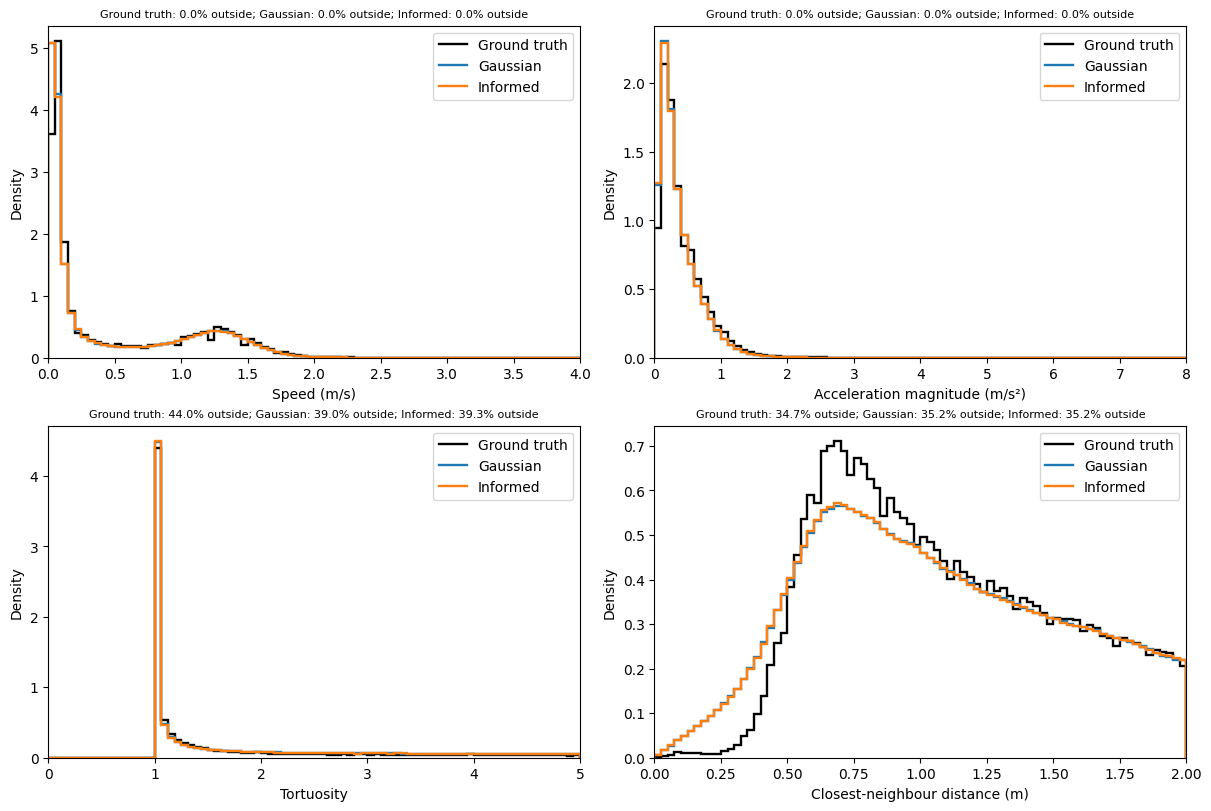

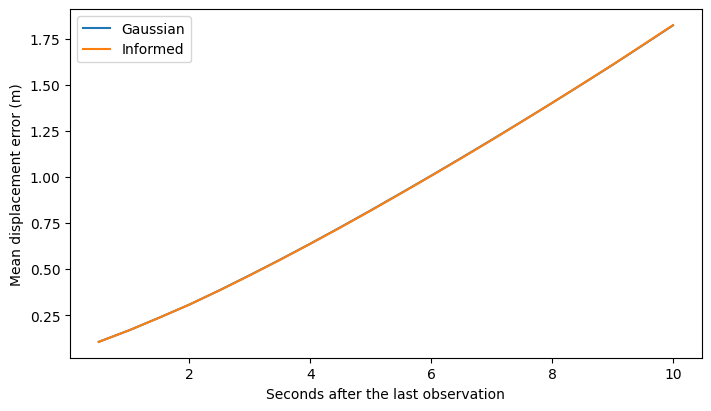

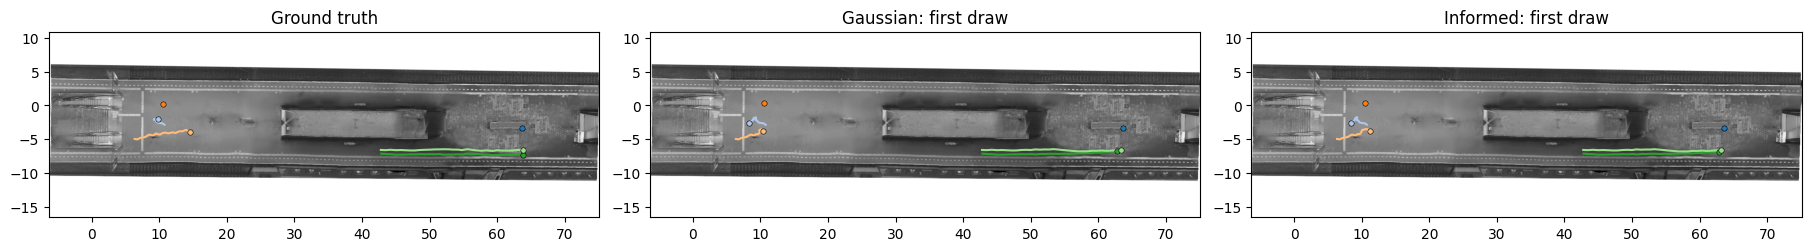

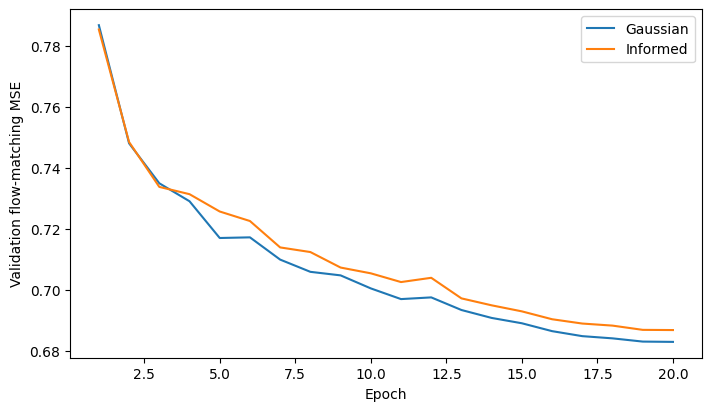

Split seed: 42; split sizes: {'train': 7000, 'validation': 1000, 'test': 2000}; futures per scene: 20
Metrics, histograms, checkpoints and split IDs saved under: C:\Users\19670\Desktop\ml4sci_ass1\assignments\part2_continued\e85b5013cdce


In [ ]:
from IPython.display import Markdown, display

results_by_prior = {"Gaussian": gaussian_results, "Informed": informed_results}
metric_names = list(gaussian_results["metrics"])
table = "| Prior | " + " | ".join(metric_names) + " |\n"
table += "| :--- | " + " | ".join(["---:"] * len(metric_names)) + " |\n"
for name, result in results_by_prior.items():
    table += "| " + name + " | " + " | ".join(f"{result['metrics'][key]:.4f}"
                                               for key in metric_names) + " |\n"
display(Markdown("Displacement errors in metres.\n\n" + table))
if not all(result["assignment_evaluation_requirements_met"] for result in results_by_prior.values()):
    display(Markdown("**Development run:** this evaluation does not meet the final "
                     "1,000-scene / 20-future requirement."))
with (OUTPUT_DIR / "pointwise_metrics.csv").open("w", newline="", encoding="utf-8") as handle:
    writer = csv.writer(handle)
    writer.writerow(["prior"] + metric_names)
    for name, result in results_by_prior.items():
        writer.writerow([name] + [result["metrics"][key] for key in metric_names])

fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
labels = dict(speed="Speed (m/s)", acceleration="Acceleration magnitude (m/s²)",
              tortuosity="Tortuosity", nearest_neighbor="Closest-neighbour distance (m)")
for ax, key in zip(axes.flat, HISTOGRAM_EDGES):
    sources = [("Ground truth", gaussian_results["histograms"]["ground_truth"][key], "black"),
               ("Gaussian", gaussian_results["histograms"]["prediction"][key], "C0"),
               ("Informed", informed_results["histograms"]["prediction"][key], "C1")]
    outside = []
    for name, hist, color in sources:
        ax.stairs(hist["density"], hist["edges"], label=name, color=color, linewidth=1.7)
        outside.append(f"{name}: {100 * hist['outside_fraction']:.1f}% outside")
    edges = HISTOGRAM_EDGES[key]
    ax.set(xlabel=labels[key], ylabel="Density", xlim=(edges[0], edges[-1]))
    ax.set_title("; ".join(outside), fontsize=8)
    ax.legend()
fig.savefig(OUTPUT_DIR / "distribution_histograms.png", dpi=180)
plt.show()

fig, ax = plt.subplots(figsize=(7, 4), constrained_layout=True)
for name, result in results_by_prior.items():
    ax.plot(np.arange(1, K + 1) * DT, result["timewise_ADE"], label=name)
ax.set(xlabel="Seconds after the last observation", ylabel="Mean displacement error (m)")
ax.legend()
fig.savefig(OUTPUT_DIR / "timewise_ade.png", dpi=180)
plt.show()

# Reuse the supplied station plot for a fixed first draw, without cherry-picking.
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5), constrained_layout=True)
examples = [("Ground truth", gaussian_example["truth"]),
            ("Gaussian: first draw", torch.cat((gaussian_example["truth"][:, :H],
                                                gaussian_example["futures"][0]), dim=1)),
            ("Informed: first draw", torch.cat((informed_example["truth"][:, :H],
                                                informed_example["futures"][0]), dim=1))]
for ax, (name, trajectory) in zip(axes, examples):
    plot_sample(trajectory, ax=ax)
    ax.set_title(name)
fig.savefig(OUTPUT_DIR / "trajectory_comparison.png", dpi=180)
plt.show()

fig, ax = plt.subplots(figsize=(7, 4), constrained_layout=True)
for name, history in (("Gaussian", gaussian_history), ("Informed", informed_history)):
    ax.plot([row["epoch"] for row in history], [row["val_loss"] for row in history], label=name)
ax.set(xlabel="Epoch", ylabel="Validation flow-matching MSE")
ax.legend()
fig.savefig(OUTPUT_DIR / "validation_losses.png", dpi=180)
plt.show()
print(f"Split seed: {CFG['seed']}; "
      f"split sizes: { {name: len(ids) for name, ids in MANIFEST['splits'].items()} }; "
      f"futures per scene: {CFG['num_futures']}")
print(f"Metrics, histograms, checkpoints and split IDs saved under: {OUTPUT_DIR.resolve()}")


## Additional trajectory examples

Six distinct test scenes are selected from observed frames only: a fixed-seed random scene, low-speed, high-speed, turning, close-neighbour and crowded examples. The first draw and 20-draw ensembles use the same sampling procedure as the main evaluation. Scene IDs and selection rules are saved. These selected-scene diagnostics supplement the full-test metrics.


In [ ]:
# Scene selection uses ONLY observed frames, never prediction errors.
EXAMPLE_SEED = CFG["seed"] + 3000
EXAMPLE_DRAWS = 20
EXAMPLE_FOCUS_COUNT = 8
EXAMPLE_DIR = OUTPUT_DIR / "qualitative_examples"
EXAMPLE_DIR.mkdir(parents=True, exist_ok=True)


def observed_scene_description(positions):
    observed = positions[:, :H]
    velocity = torch.diff(observed, dim=1) / DT
    speed = velocity.norm(dim=-1).mean(dim=1)
    path = torch.diff(observed, dim=1).norm(dim=-1).sum(dim=1)
    net = (observed[:, -1] - observed[:, 0]).norm(dim=-1).clamp_min(0.01)
    # Exclude nearly stationary pedestrians when looking for turning examples.
    turning = torch.where(speed > 0.3, path / net, torch.zeros_like(path))
    distances = torch.cdist(observed[:, -1], observed[:, -1])
    distances.fill_diagonal_(float("inf"))
    return dict(num_pedestrians=len(positions), median_speed=speed.median().item(),
                turning_score=turning.max().item(),
                nearest_distance=distances.min().item())


def select_example_scenes(test_subset, seed):
    descriptions = [observed_scene_description(test_subset.dataset.raw_data[index])
                    for index in test_subset.indices]
    rng = np.random.default_rng(seed)
    first = int(rng.integers(len(descriptions)))
    selections = [("random", "Fixed-seed random scene", first)]
    used = {first}
    criteria = [("slow", "Lowest median observed speed", "median_speed", False),
                ("fast", "Highest median observed speed", "median_speed", True),
                ("turning", "Largest observed path / displacement for a moving pedestrian", "turning_score", True),
                ("close", "Smallest observed closest-neighbour distance", "nearest_distance", False),
                ("crowded", "Largest observed pedestrian count", "num_pedestrians", True)]
    for label, reason, feature, descending in criteria:
        ranking = sorted(range(len(descriptions)),
                         key=lambda index: descriptions[index][feature], reverse=descending)
        available = next((index for index in ranking if index not in used), None)
        if available is None:
            break
        selections.append((label, reason, available))
        used.add(available)
    return selections, descriptions


def choose_display_pedestrians(positions, label, count=8):
    observed = positions[:, :H]
    steps = torch.diff(observed, dim=1)
    speed = (steps / DT).norm(dim=-1).mean(dim=1)
    curvature = steps.norm(dim=-1).sum(dim=1) / (
        observed[:, -1] - observed[:, 0]).norm(dim=-1).clamp_min(0.01)
    if label in ("close", "crowded"):
        distances = torch.cdist(observed[:, -1], observed[:, -1])
        distances.fill_diagonal_(float("inf"))
        focus = int(distances.min(dim=1).values.argmin())
    elif label == "turning":
        score = torch.where(speed > 0.3, curvature, torch.zeros_like(curvature))
        focus = int(score.argmax())
    elif label == "slow":
        focus = int(speed.argmin())
    else:
        focus = int(speed.argmax())
    # Show the focal pedestrian plus nearby pedestrians; selection uses p^9.
    distance_to_focus = (observed[:, -1] - observed[focus, -1]).norm(dim=-1)
    nearby = distance_to_focus.argsort().tolist()
    display_ids = [focus] + [index for index in nearby if index != focus][:count - 1]
    return display_ids, focus


def example_metrics(predicted, truth):
    error = (predicted - truth[None, :, H:]).norm(dim=-1)
    ade, fde = error.mean(dim=(1, 2)), error[:, :, -1].mean(dim=1)
    endpoints = predicted[:, :, -1]
    rms_spread = (endpoints - endpoints.mean(dim=0)).square().sum(dim=-1).mean(dim=0).sqrt().mean()
    return dict(ADE=ade.mean().item(), FDE=fde.mean().item(),
                min20ADE=ade.min().item(), min20FDE=fde.min().item(),
                endpoint_RMS_spread=rms_spread.item())


example_selections, example_descriptions = select_example_scenes(data_module.test_data, EXAMPLE_SEED)
trajectory_examples = []
for label, reason, test_index in example_selections:
    batch = next(iter(DataLoader([data_module.test_data[test_index]], batch_size=1))).to(DEVICE)
    # Common random numbers make the comparison controlled; the 20 draws within
    # either model are still distinct stochastic scene futures.
    draw_seed = EXAMPLE_SEED + test_index
    futures = {}
    for name, model, prior in (("Gaussian", gaussian_model, "gaussian"),
                                ("Informed", informed_model, "informed")):
        rng = torch.Generator(device=DEVICE).manual_seed(draw_seed)
        with torch.no_grad():
            futures[name] = sample_future(model, batch, prior, num_samples=EXAMPLE_DRAWS,
                                         steps=CFG["ode_steps"], generator=rng).cpu()
    truth = batch.x.cpu()
    display_ids, focus = choose_display_pedestrians(truth, label, EXAMPLE_FOCUS_COUNT)
    dataset_index = data_module.test_data.indices[test_index]
    raw_scene_id = dataset.original_ids[dataset_index]
    metrics = {name: example_metrics(predicted, truth) for name, predicted in futures.items()}
    example = dict(label=label, selection_reason=reason, test_index=test_index,
                   raw_scene_id=raw_scene_id, draw_seed=draw_seed,
                   observed_description=example_descriptions[test_index],
                   display_ids=display_ids, focus_pedestrian=focus, metrics=metrics,
                   truth=truth, futures=futures)
    trajectory_examples.append(example)
    print(f"{label}: scene {raw_scene_id}, {len(truth)} pedestrians; {reason}")

example_manifest = [
    {key: value for key, value in example.items() if key not in ("truth", "futures")}
    for example in trajectory_examples]
(EXAMPLE_DIR / "example_manifest.json").write_text(
    json.dumps(dict(selection_seed=EXAMPLE_SEED, num_futures=EXAMPLE_DRAWS,
                    run_id=RUN_ID, examples=example_manifest), indent=2), encoding="utf-8")
torch.save([{key: value for key, value in example.items()
             if key in ("label", "raw_scene_id", "truth", "futures")}
            for example in trajectory_examples], EXAMPLE_DIR / "example_futures.pt")

summary = "| Example | Scene ID | N | Prior | ADE | FDE | min20ADE | min20FDE | Endpoint RMS spread |\n"
summary += "| :--- | ---: | ---: | :--- | ---: | ---: | ---: | ---: | ---: |\n"
for example in trajectory_examples:
    for name, metrics in example["metrics"].items():
        values = " | ".join(f"{metrics[key]:.3f}" for key in
                            ("ADE", "FDE", "min20ADE", "min20FDE", "endpoint_RMS_spread"))
        summary += (f"| {example['label']} | {example['raw_scene_id']} | {len(example['truth'])} "
                    f"| {name} | {values} |\n")
display(Markdown("Selected-scene diagnostics in metres; all pedestrians contribute to metrics. "
                 "Endpoint RMS spread measures sample variability, not error.\n\n" + summary))


random: scene 92815, 49 pedestrians; Fixed-seed random scene


slow: scene 13863, 5 pedestrians; Lowest median observed speed


fast: scene 0, 5 pedestrians; Highest median observed speed


turning: scene 57725, 16 pedestrians; Largest observed path / displacement for a moving pedestrian


close: scene 58039, 36 pedestrians; Smallest observed closest-neighbour distance


crowded: scene 35480, 100 pedestrians; Largest observed pedestrian count


Selected-scene diagnostics in metres; all pedestrians contribute to metrics. Endpoint RMS spread measures sample variability, not error.

| Example | Scene ID | N | Prior | ADE | FDE | min20ADE | min20FDE | Endpoint RMS spread |
| :--- | ---: | ---: | :--- | ---: | ---: | ---: | ---: | ---: |
| random | 92815 | 49 | Gaussian | 1.062 | 1.837 | 0.898 | 1.473 | 1.626 |
| random | 92815 | 49 | Informed | 1.040 | 1.799 | 0.899 | 1.488 | 1.523 |
| slow | 13863 | 5 | Gaussian | 0.557 | 1.138 | 0.198 | 0.158 | 1.291 |
| slow | 13863 | 5 | Informed | 0.560 | 1.162 | 0.245 | 0.287 | 1.351 |
| fast | 0 | 5 | Gaussian | 5.362 | 11.405 | 3.730 | 7.891 | 4.668 |
| fast | 0 | 5 | Informed | 5.878 | 12.093 | 4.405 | 8.643 | 4.358 |
| turning | 57725 | 16 | Gaussian | 1.633 | 2.967 | 1.356 | 2.052 | 2.753 |
| turning | 57725 | 16 | Informed | 1.681 | 3.029 | 1.341 | 2.239 | 2.751 |
| close | 58039 | 36 | Gaussian | 1.386 | 2.964 | 1.198 | 2.454 | 2.169 |
| close | 58039 | 36 | Informed | 1.386 | 2.947 | 1.204 | 2.441 | 2.161 |
| crowded | 35480 | 100 | Gaussian | 0.993 | 1.914 | 0.866 | 1.693 | 1.494 |
| crowded | 35480 | 100 | Informed | 1.005 | 1.941 | 0.870 | 1.705 | 1.512 |


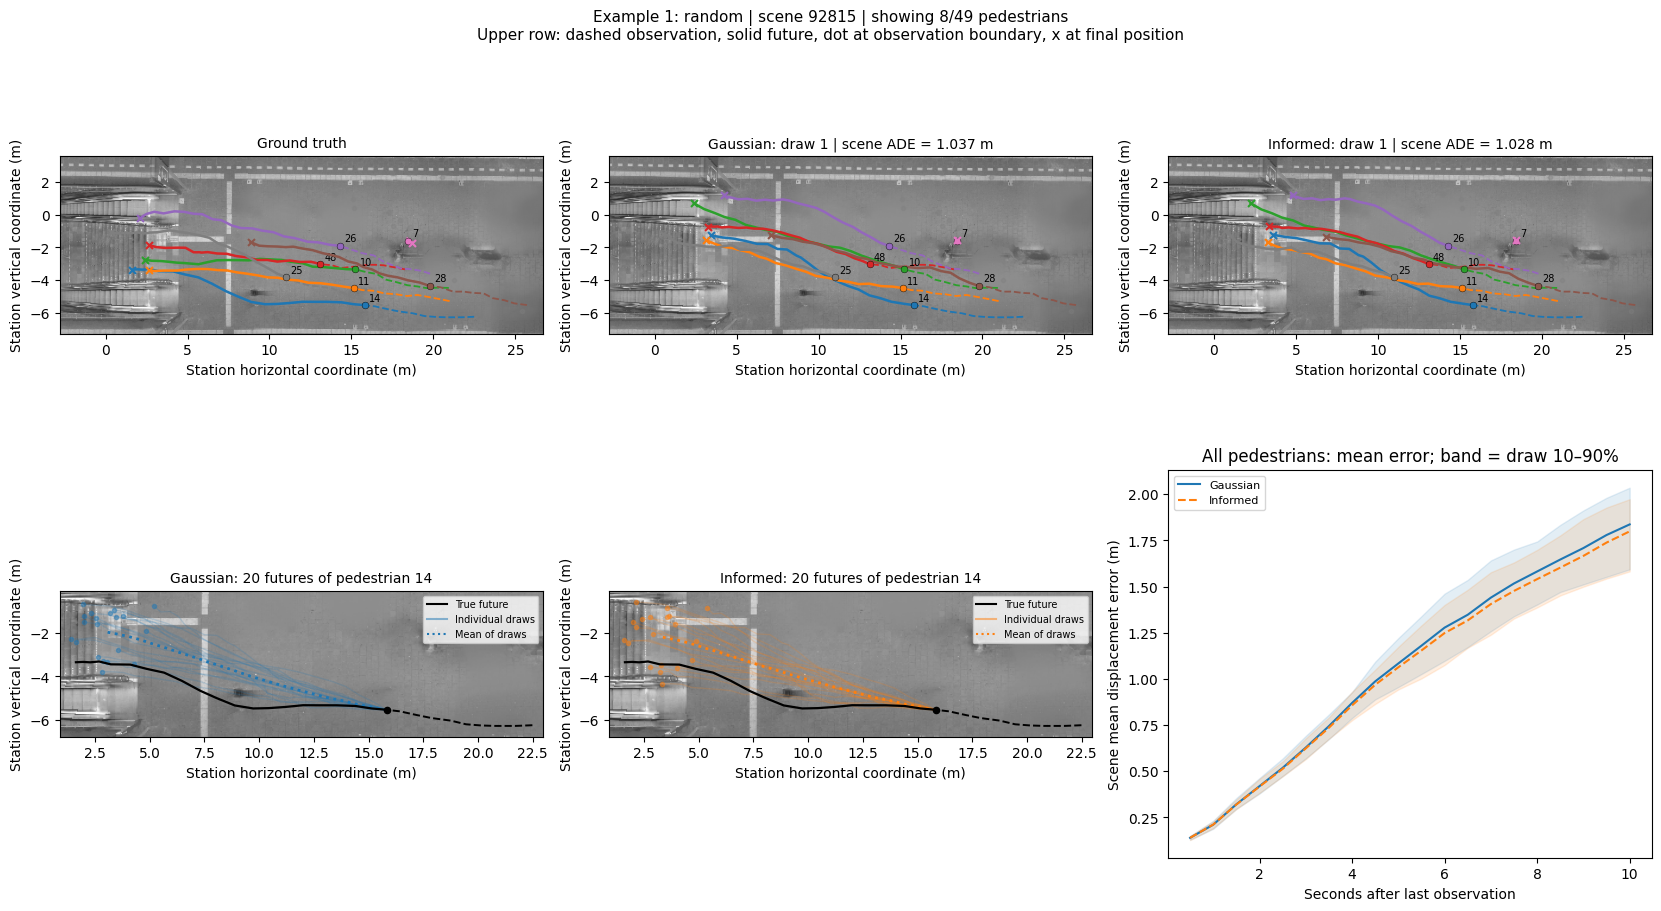

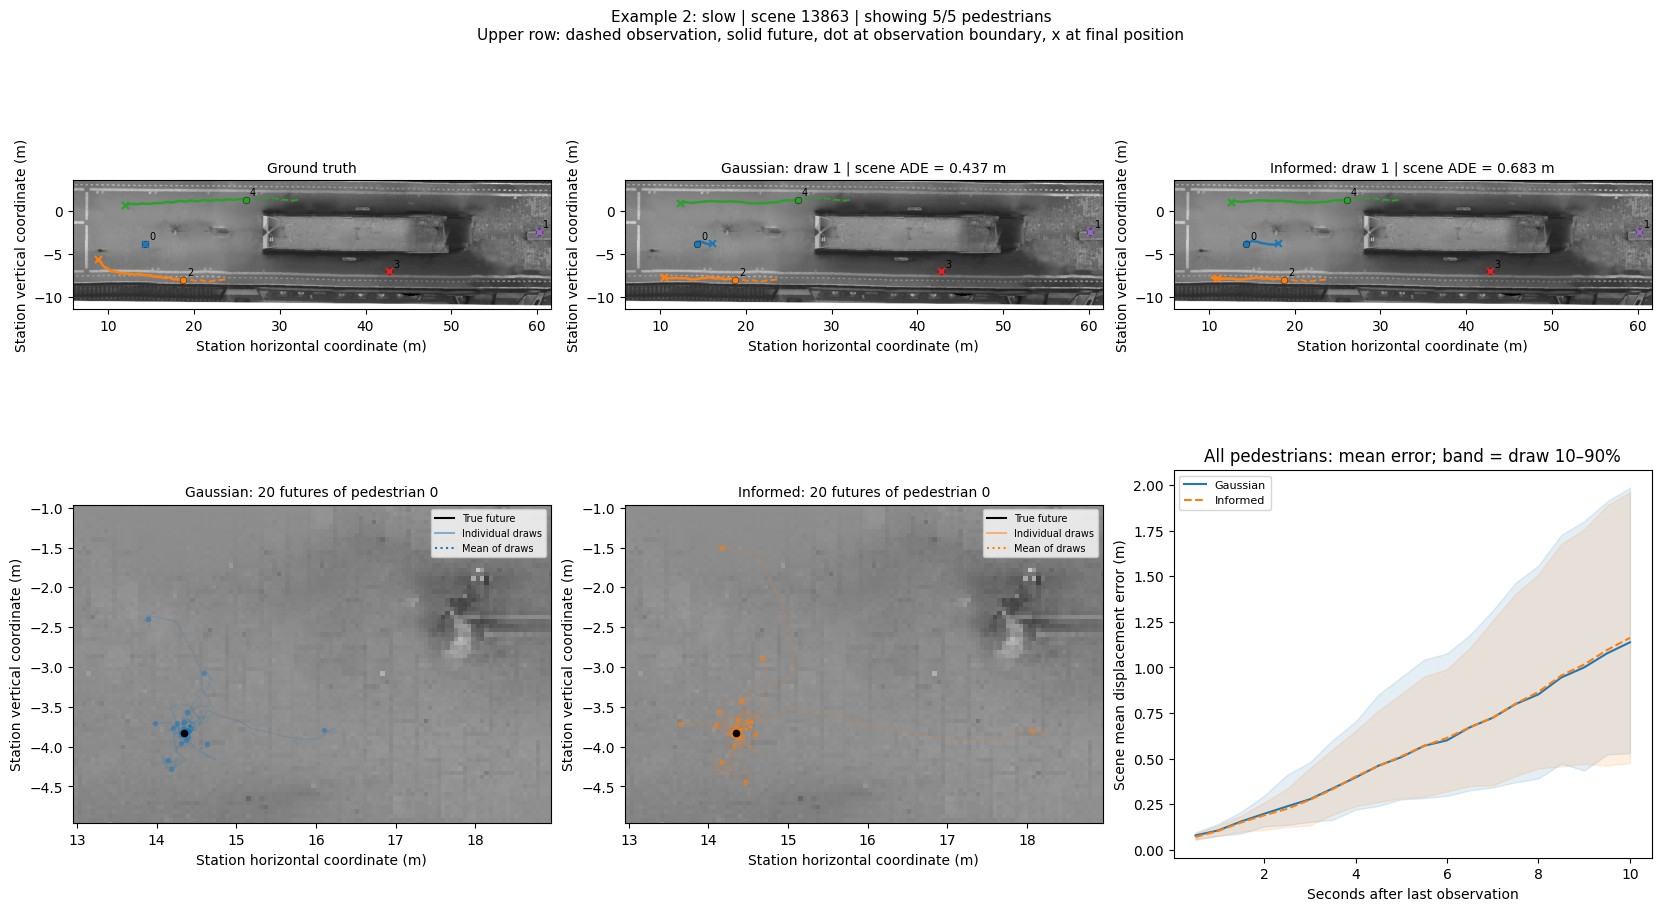

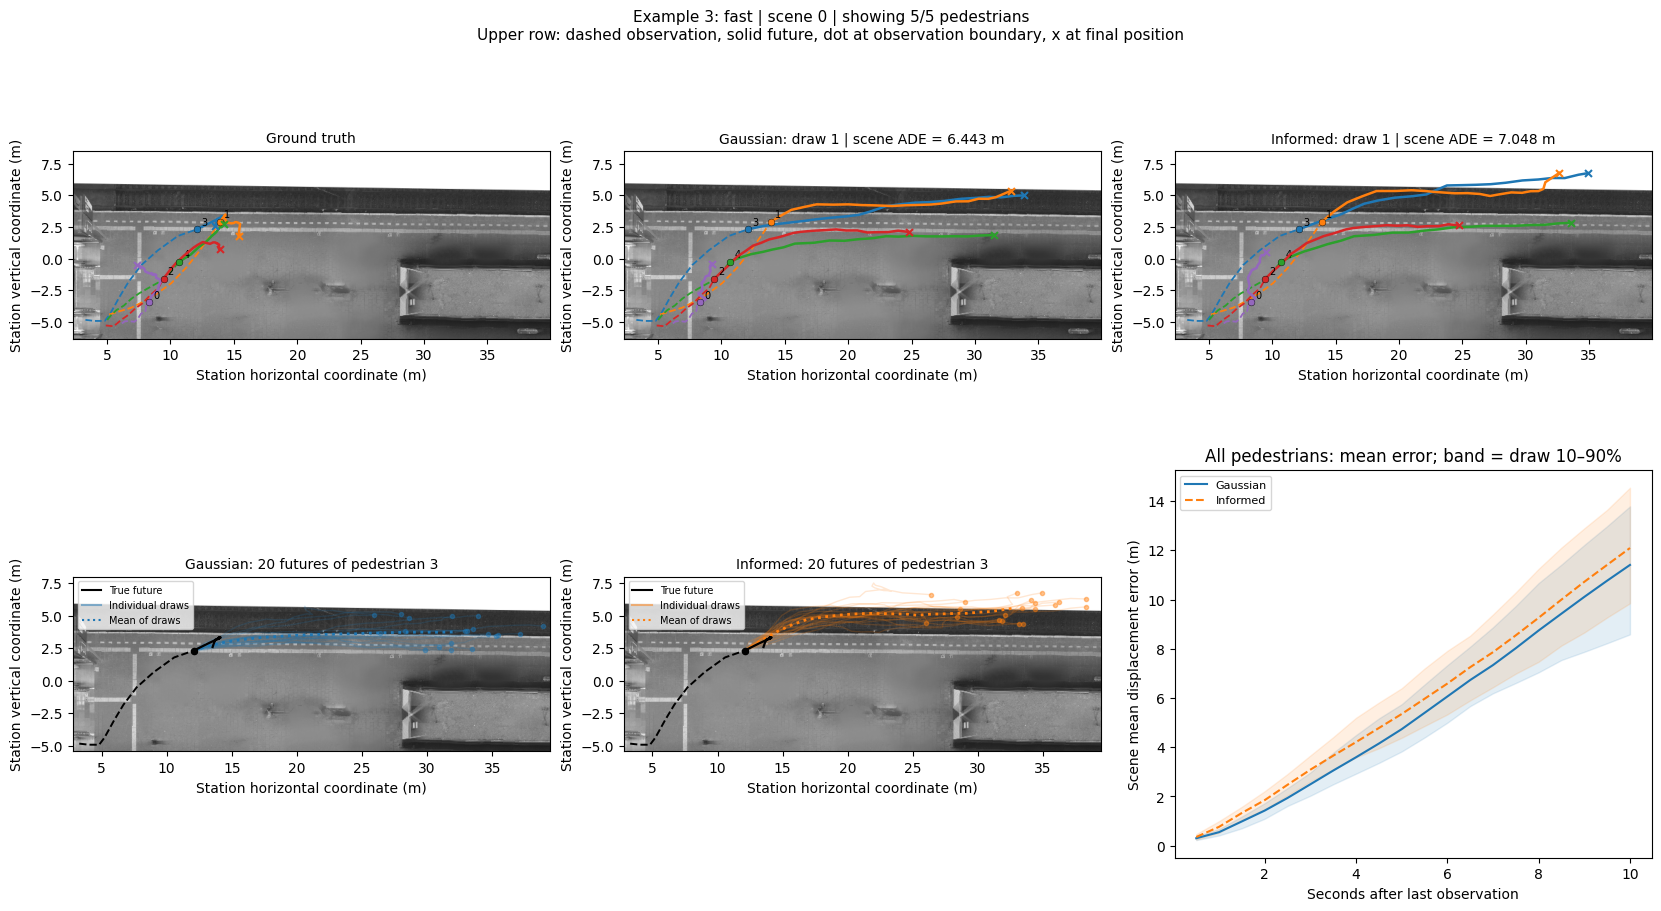

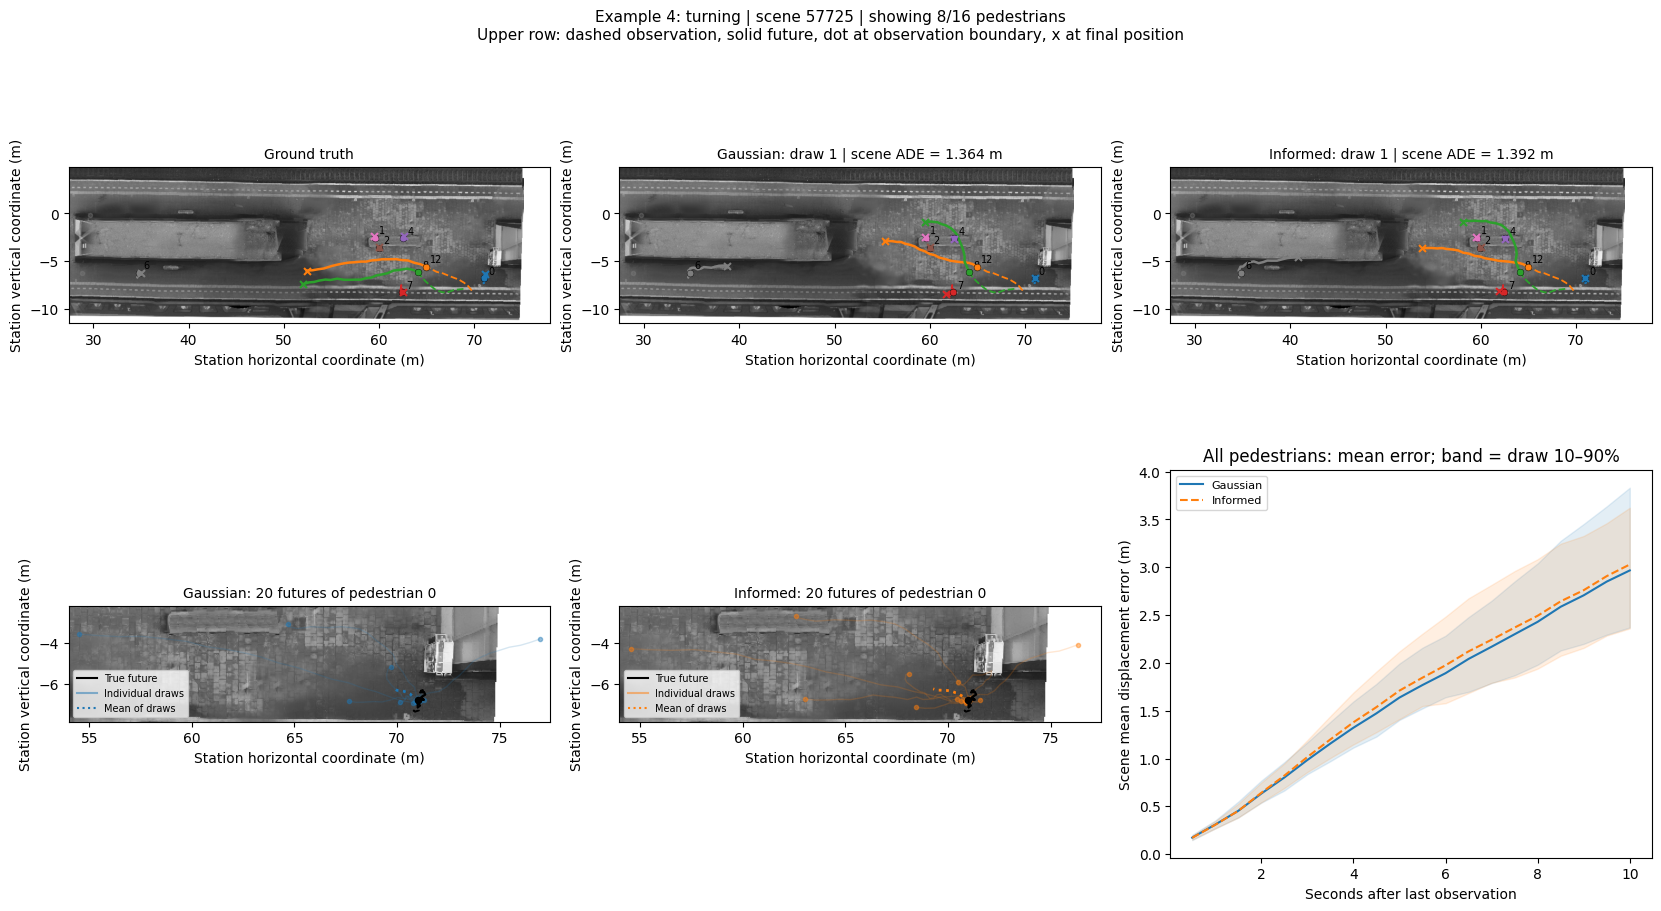

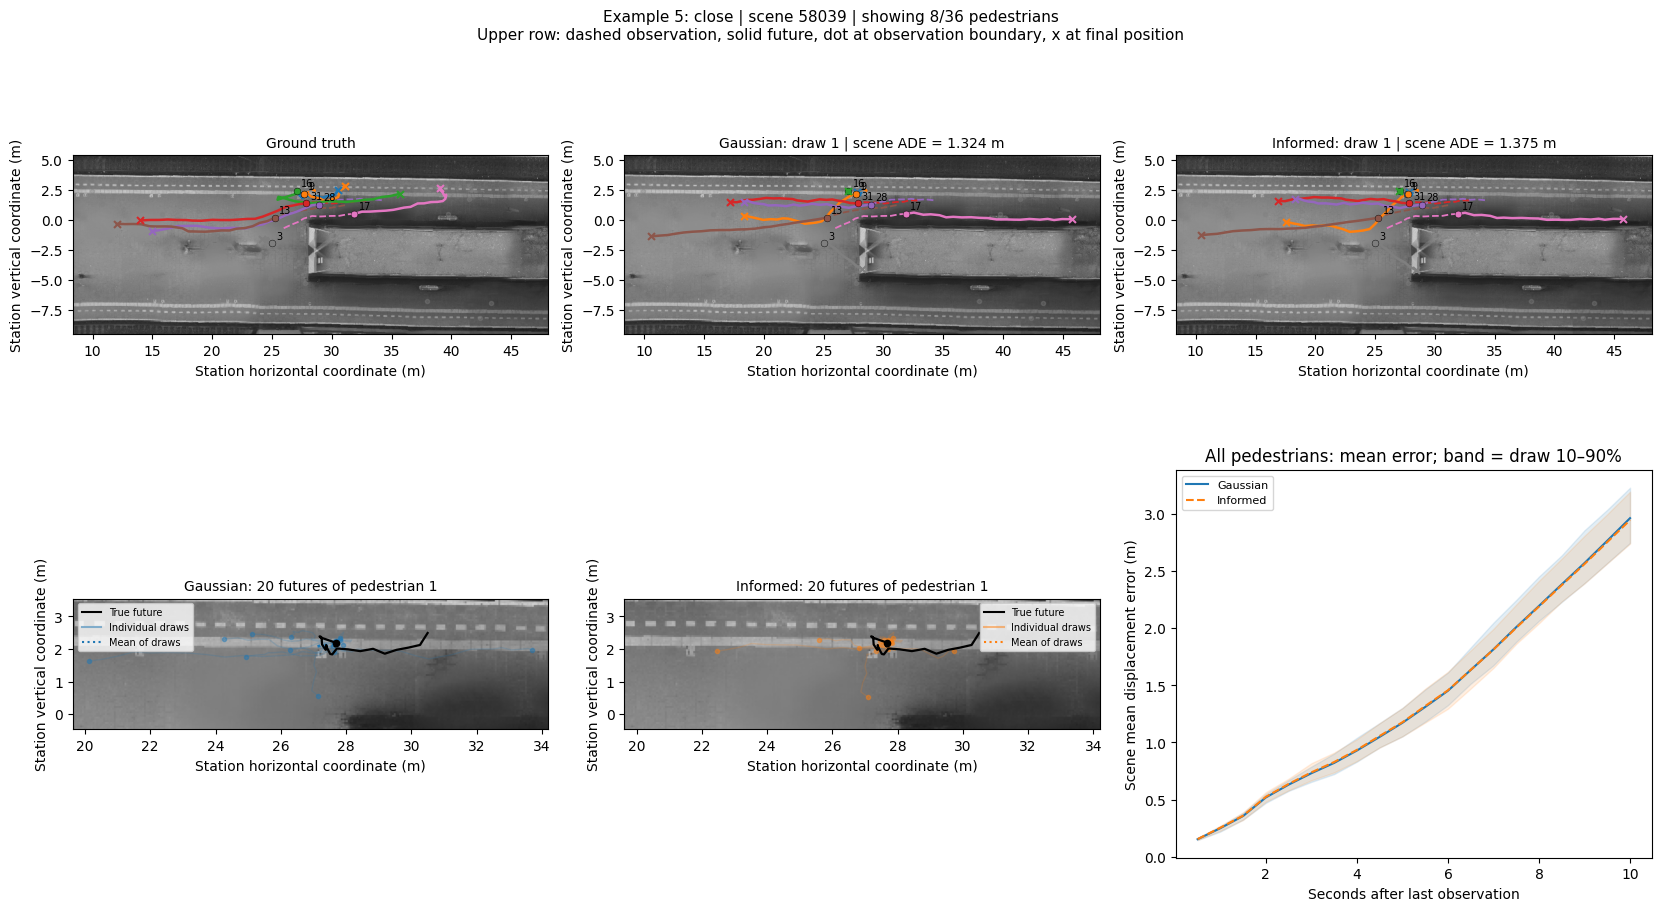

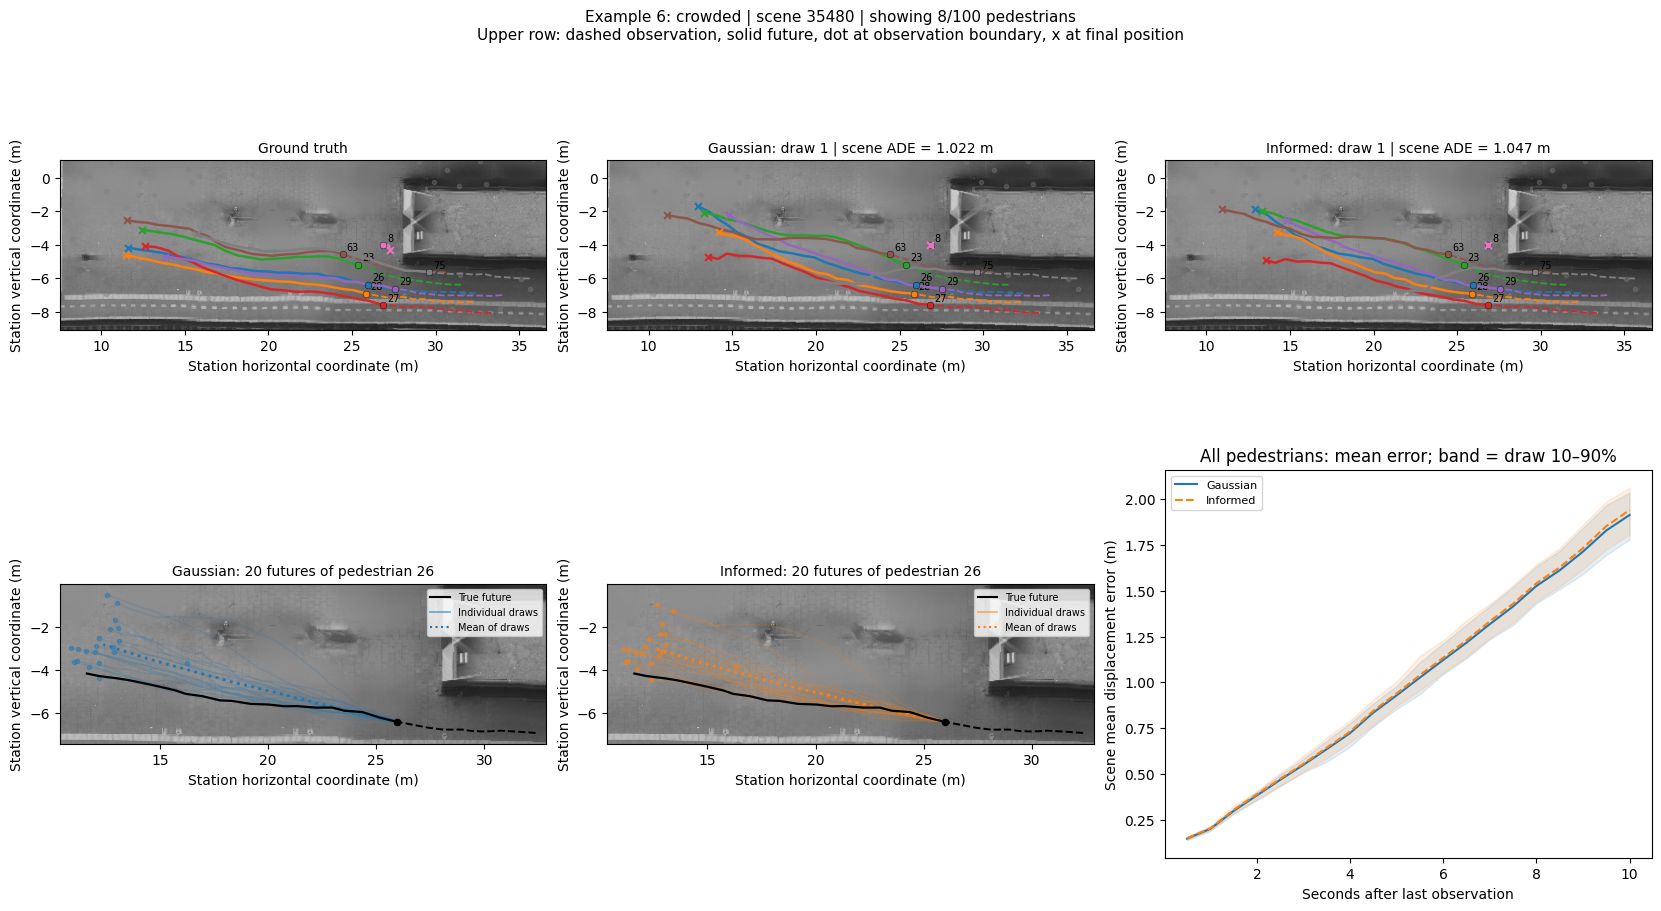

Saved 6 scene comparisons, their 20 sampled futures and selection manifest under: C:\Users\19670\Desktop\ml4sci_ass1\assignments\part2_continued\e85b5013cdce\qualitative_examples


In [ ]:
from matplotlib.lines import Line2D


def station_background(ax):
    ax.imshow(plt.imread("Eindhoven_centraal_platform_3_4.png"),
              extent=EXTENT, origin="upper", zorder=0)
    ax.set(xlabel="Station horizontal coordinate (m)",
           ylabel="Station vertical coordinate (m)")
    ax.set_aspect("equal", adjustable="box")


def trajectory_limits(trajectories, padding=1.0):
    # Same limits for both models; include truth and every displayed draw.
    points = torch.cat([value.reshape(-1, 2) for value in trajectories]).numpy()[:, [1, 0]]
    low, high = points.min(axis=0), points.max(axis=0)
    width, height = max(float(high[0] - low[0]) + 2 * padding, 6), max(float(high[1] - low[1]) + 2 * padding, 4)
    centre = (low + high) / 2
    return ((centre[0] - width / 2, centre[0] + width / 2),
            (centre[1] - height / 2, centre[1] + height / 2))


def set_trajectory_limits(ax, limits):
    ax.set_xlim(*limits[0])
    ax.set_ylim(*limits[1])


def draw_scene_example(ax, truth, future, display_ids, limits, title):
    station_background(ax)
    observed = truth[:, :H]
    anchors = observed[:, -1].numpy()[:, [1, 0]]
    ax.scatter(anchors[:, 0], anchors[:, 1], c="0.5", s=9, alpha=0.35, zorder=1)
    colors = plt.get_cmap("tab10")
    for slot, pedestrian in enumerate(display_ids):
        color = colors(slot % 10)
        history = observed[pedestrian].numpy()[:, [1, 0]]
        predicted = torch.cat((observed[pedestrian, -1:], future[pedestrian]), dim=0).numpy()[:, [1, 0]]
        ax.plot(history[:, 0], history[:, 1], ls="--", color=color, lw=1.3, zorder=2)
        ax.plot(predicted[:, 0], predicted[:, 1], color=color, lw=1.8, zorder=3)
        ax.scatter(*history[-1], color=color, edgecolor="black", linewidth=0.3, s=24, zorder=4)
        ax.scatter(*predicted[-1], color=color, marker="x", s=25, zorder=4)
        ax.annotate(str(pedestrian), history[-1], xytext=(3, 3), textcoords="offset points", fontsize=7)
    set_trajectory_limits(ax, limits)
    ax.set_title(title, fontsize=10)


def draw_ensemble_example(ax, truth, futures, focus, limits, name, color):
    station_background(ax)
    observed = truth[focus, :H].numpy()[:, [1, 0]]
    actual = truth[focus, H-1:].numpy()[:, [1, 0]]
    for future in futures[:, focus]:
        path = torch.cat((truth[focus, H-1:H], future), dim=0).numpy()[:, [1, 0]]
        ax.plot(path[:, 0], path[:, 1], color=color, alpha=0.18, lw=1.0, zorder=2)
        ax.scatter(*path[-1], color=color, s=9, alpha=0.45, zorder=3)
    average = torch.cat((truth[focus, H-1:H], futures[:, focus].mean(dim=0)), dim=0).numpy()[:, [1, 0]]
    ax.plot(average[:, 0], average[:, 1], color=color, lw=2.0, ls=":", zorder=4)
    ax.plot(actual[:, 0], actual[:, 1], color="black", lw=1.6, zorder=5)
    ax.plot(observed[:, 0], observed[:, 1], color="black", lw=1.4, ls="--", zorder=5)
    ax.scatter(*observed[-1], color="black", s=20, zorder=6)
    set_trajectory_limits(ax, limits)
    ax.set_title(f"{name}: 20 futures of pedestrian {focus}", fontsize=10)
    ax.legend(handles=[Line2D([0], [0], color="black", label="True future"),
                       Line2D([0], [0], color=color, alpha=0.5, label="Individual draws"),
                       Line2D([0], [0], color=color, ls=":", label="Mean of draws")],
              fontsize=7, loc="best")


for number, example in enumerate(trajectory_examples, start=1):
    truth, futures = example["truth"], example["futures"]
    display_ids, focus = example["display_ids"], example["focus_pedestrian"]
    # Upper row: identical pedestrians, colors, crop and draw number.
    # Lower row: all 20 sampled futures of a single observed-only chosen pedestrian.
    scene_limits = trajectory_limits([truth[display_ids],
                                     futures["Gaussian"][:, display_ids],
                                     futures["Informed"][:, display_ids]])
    focus_limits = trajectory_limits([truth[focus], futures["Gaussian"][:, focus],
                                      futures["Informed"][:, focus]], padding=0.5)
    fig, axes = plt.subplots(2, 3, figsize=(16.5, 9), constrained_layout=True)
    title = (f"Example {number}: {example['label']} | scene {example['raw_scene_id']} | "
             f"showing {len(display_ids)}/{len(truth)} pedestrians\n"
             "Upper row: dashed observation, solid future, dot at observation boundary, x at final position")
    fig.suptitle(title, fontsize=11)
    draw_scene_example(axes[0, 0], truth, truth[:, H:], display_ids, scene_limits, "Ground truth")
    for column, name in enumerate(("Gaussian", "Informed"), start=1):
        first_draw_error = (futures[name][0] - truth[:, H:]).norm(dim=-1).mean().item()
        draw_scene_example(axes[0, column], truth, futures[name][0], display_ids, scene_limits,
                           f"{name}: draw 1 | scene ADE = {first_draw_error:.3f} m")
    draw_ensemble_example(axes[1, 0], truth, futures["Gaussian"], focus, focus_limits, "Gaussian", "C0")
    draw_ensemble_example(axes[1, 1], truth, futures["Informed"], focus, focus_limits, "Informed", "C1")
    ax = axes[1, 2]
    seconds = np.arange(1, K + 1) * DT
    for name, color, linestyle in (("Gaussian", "C0", "-"), ("Informed", "C1", "--")):
        # Average over all pedestrians first; the band describes variation across
        # scene draws, not a confidence interval for the model comparison.
        errors = (futures[name] - truth[None, :, H:]).norm(dim=-1).mean(dim=1)
        lower, upper = torch.quantile(errors, torch.tensor([0.1, 0.9]), dim=0).numpy()
        ax.plot(seconds, errors.mean(dim=0).numpy(), color=color, ls=linestyle, label=name)
        ax.fill_between(seconds, lower, upper, color=color, alpha=0.12)
    ax.set(xlabel="Seconds after last observation", ylabel="Scene mean displacement error (m)",
           title="All pedestrians: mean error; band = draw 10–90%")
    ax.legend(fontsize=8)
    fig.savefig(EXAMPLE_DIR / f"{number:02d}_{example['label']}_comparison.png", dpi=150)
    plt.show()
    plt.close(fig)

print(f"Saved {len(trajectory_examples)} scene comparisons, their 20 sampled futures "
      f"and selection manifest under: {EXAMPLE_DIR.resolve()}")
